# Ejercicio 1 — Modelos LSTM

Dos series (`total` y `via_aerea`), dos familias de modelos LSTM por serie con tuneo de hiperparámetros, predicción con el mejor modelo, y comparación contra los mejores modelos clásicos del Laboratorio 1. Usa exactamente el mismo train/test que el Laboratorio 1 (ver `datos_comunes.py`).

In [1]:
import sys
sys.path.insert(0, ".")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from datos_comunes import cargar_series

tf.random.set_seed(42)
np.random.seed(42)

OUT_DIR = "resultados"
VENTANA = 12
SERIES_ELEGIDAS = ["total", "via_aerea"]

## Datos: mismas series y particiones que el Laboratorio 1

In [2]:
series_train, series_test, labels = cargar_series()
for n in labels:
    print(f"{n:15s} train={len(series_train[n]):3d}  test={len(series_test[n]):3d}  {labels[n]}")

total           train=147  test= 63  Total mensual de viajeros (Turista+Excursionista)
via_aerea       train=147  test= 63  Viajeros por vía Aérea
via_terrestre   train=147  test= 63  Viajeros por vía Terrestre
via_maritima    train=147  test= 63  Viajeros por vía Marítima
region1         train=147  test= 63  Viajeros por región: América Del Centro
region2         train=147  test= 63  Viajeros por región: América Del Norte
region3         train=147  test= 63  Viajeros por región: Europa


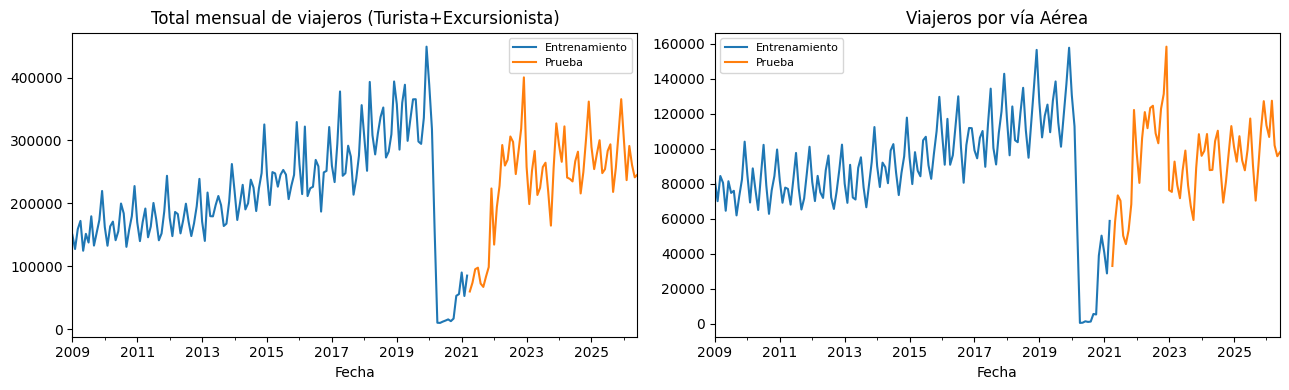

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, nombre in zip(axes, SERIES_ELEGIDAS):
    series_train[nombre].plot(ax=ax, label="Entrenamiento")
    series_test[nombre].plot(ax=ax, label="Prueba")
    ax.set_title(labels[nombre])
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Funciones auxiliares: ventanas, arquitectura y métricas

In [4]:
def crear_ventanas(arr, ventana):
    x, y = [], []
    for i in range(len(arr) - ventana):
        x.append(arr[i:i + ventana])
        y.append(arr[i + ventana])
    return np.array(x), np.array(y)


def construir_modelo(tipo, units, lr=0.001, dropout=0.0):
    modelo = Sequential()
    modelo.add(Input(shape=(VENTANA, 1)))
    if tipo == "simple":
        modelo.add(LSTM(units))
    else:  # "dropout"
        modelo.add(LSTM(units))
        modelo.add(Dropout(dropout))
    modelo.add(Dense(1))
    modelo.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return modelo


def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

## Tuneo de hiperparámetros

Dos familias de modelos:
- **Modelo 1 (LSTM simple):** una capa LSTM + capa densa de salida. Se tunean `units` (32/64) y `learning_rate` (0.001/0.01).
- **Modelo 2 (LSTM + Dropout):** una capa LSTM, Dropout de regularización, y capa densa de salida. Se tunean `units` (32/64) y `dropout` (0.1/0.3).

La selección del mejor config de cada familia se hace con un recorte de validación (últimos meses del set de entrenamiento).

In [5]:
def tunear_serie(nombre, train, test):
    print(f"\n{'='*70}\nSERIE: {nombre}  (train={len(train)}, test={len(test)})\n{'='*70}")

    scaler = MinMaxScaler()
    train_esc = scaler.fit_transform(train.values.reshape(-1, 1))
    test_esc = scaler.transform(test.values.reshape(-1, 1))

    x_all, y_all = crear_ventanas(train_esc, VENTANA)
    n_val = max(12, int(len(x_all) * 0.2))
    x_tr, y_tr = x_all[:-n_val], y_all[:-n_val]
    x_val, y_val = x_all[-n_val:], y_all[-n_val:]

    serie_para_test = np.concatenate([train_esc[-VENTANA:], test_esc])
    x_test, y_test = crear_ventanas(serie_para_test, VENTANA)

    grid = []
    for units in (32, 64):
        for lr in (0.001, 0.01):
            grid.append(("Modelo 1 (LSTM simple)", "simple", units, lr, 0.0))
    for units in (32, 64):
        for dropout in (0.1, 0.3):
            grid.append(("Modelo 2 (LSTM + Dropout)", "dropout", units, 0.001, dropout))

    registros = []
    mejores = {}
    for etiqueta, tipo, units, lr, dropout in grid:
        modelo = construir_modelo(tipo, units, lr, dropout)
        es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
        modelo.fit(x_tr, y_tr, validation_data=(x_val, y_val),
                   epochs=150, batch_size=16, verbose=0, callbacks=[es])
        val_pred = modelo.predict(x_val, verbose=0)
        val_mae, val_rmse = evaluar(y_val, val_pred)

        reg = {"serie": nombre, "familia": etiqueta, "units": units,
               "learning_rate": lr, "dropout": dropout, "val_MAE": val_mae,
               "val_RMSE": val_rmse}
        registros.append(reg)
        print(f"  {etiqueta:28s} units={units:3d} lr={lr:<6} dropout={dropout:<4} "
              f"-> val_RMSE(escala 0-1)={val_rmse:.4f}")

        if etiqueta not in mejores or val_rmse < mejores[etiqueta]["val_RMSE"]:
            mejores[etiqueta] = reg

    tabla_grid = pd.DataFrame(registros)

    finales = []
    for etiqueta, reg in mejores.items():
        tipo = "simple" if "simple" in etiqueta else "dropout"
        modelo = construir_modelo(tipo, reg["units"], reg["learning_rate"], reg["dropout"])
        es = EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)
        modelo.fit(x_all, y_all, epochs=150, batch_size=16, verbose=0, callbacks=[es])

        pred_esc = modelo.predict(x_test, verbose=0)
        pred = scaler.inverse_transform(pred_esc).flatten()
        real = scaler.inverse_transform(y_test).flatten()
        mae, rmse = evaluar(real, pred)

        finales.append({**reg, "test_MAE": mae, "test_RMSE": rmse,
                         "pred": pred, "real": real})
        print(f"  --> {etiqueta} finalista: test MAE={mae:,.0f}  RMSE={rmse:,.0f}")

    mejor_final = min(finales, key=lambda r: r["test_RMSE"])
    print(f"\n  ### Mejor modelo LSTM para '{nombre}': {mejor_final['familia']} "
          f"(units={mejor_final['units']}, lr={mejor_final['learning_rate']}, "
          f"dropout={mejor_final['dropout']}) "
          f"-> test MAE={mejor_final['test_MAE']:,.0f}  RMSE={mejor_final['test_RMSE']:,.0f}")

    fig, ax = plt.subplots(figsize=(11, 4.5))
    idx = test.index[-len(mejor_final["real"]):]
    ax.plot(idx, mejor_final["real"], label="Real", color="black", lw=2)
    for f in finales:
        ax.plot(idx, f["pred"], "--", label=f"{f['familia']} (pred)")
    ax.set_title(f"Predicción en test - {nombre}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/ej1_pred_{nombre}.png", dpi=120)
    plt.show()

    return tabla_grid, finales, mejor_final

## Ejecución del tuneo y comparación para las dos series


SERIE: total  (train=147, test=63)


  Modelo 1 (LSTM simple)       units= 32 lr=0.001  dropout=0.0  -> val_RMSE(escala 0-1)=0.2787


  Modelo 1 (LSTM simple)       units= 32 lr=0.01   dropout=0.0  -> val_RMSE(escala 0-1)=0.2379


  Modelo 1 (LSTM simple)       units= 64 lr=0.001  dropout=0.0  -> val_RMSE(escala 0-1)=0.2928


  Modelo 1 (LSTM simple)       units= 64 lr=0.01   dropout=0.0  -> val_RMSE(escala 0-1)=0.2349


...

  Modelo 2 (LSTM + Dropout)    units= 32 lr=0.001  dropout=0.3  -> val_RMSE(escala 0-1)=0.2741


  Modelo 2 (LSTM + Dropout)    units= 64 lr=0.001  dropout=0.1  -> val_RMSE(escala 0-1)=0.2874


  Modelo 2 (LSTM + Dropout)    units= 64 lr=0.001  dropout=0.3  -> val_RMSE(escala 0-1)=0.2838


  --> Modelo 1 (LSTM simple) finalista: test MAE=35,687  RMSE=46,500


  --> Modelo 2 (LSTM + Dropout) finalista: test MAE=39,389  RMSE=50,616

  ### Mejor modelo LSTM para 'total': Modelo 1 (LSTM simple) (units=64, lr=0.01, dropout=0.0) -> test MAE=35,687  RMSE=46,500


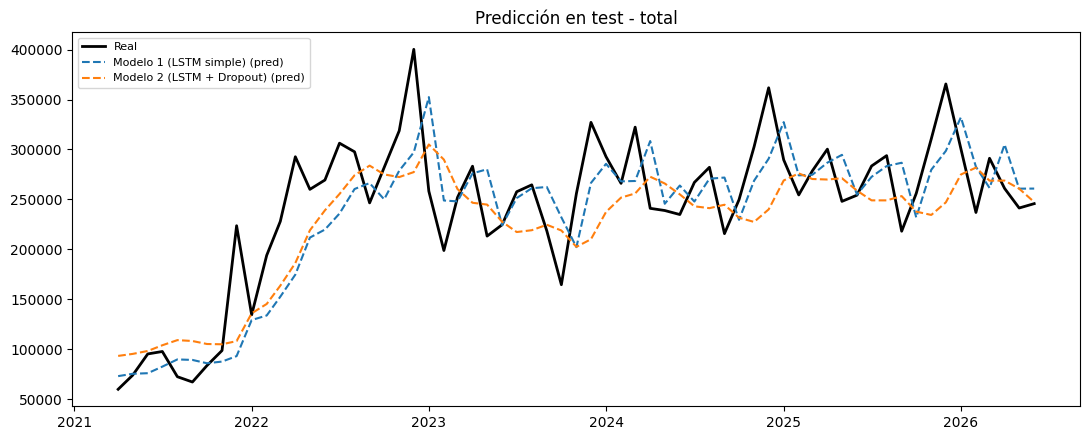


SERIE: via_aerea  (train=147, test=63)


  Modelo 1 (LSTM simple)       units= 32 lr=0.001  dropout=0.0  -> val_RMSE(escala 0-1)=0.3204


  Modelo 1 (LSTM simple)       units= 32 lr=0.01   dropout=0.0  -> val_RMSE(escala 0-1)=0.2482


  Modelo 1 (LSTM simple)       units= 64 lr=0.001  dropout=0.0  -> val_RMSE(escala 0-1)=0.2766


  Modelo 1 (LSTM simple)       units= 64 lr=0.01   dropout=0.0  -> val_RMSE(escala 0-1)=0.2502


...

  Modelo 2 (LSTM + Dropout)    units= 32 lr=0.001  dropout=0.3  -> val_RMSE(escala 0-1)=0.2576


  Modelo 2 (LSTM + Dropout)    units= 64 lr=0.001  dropout=0.1  -> val_RMSE(escala 0-1)=0.2809


  Modelo 2 (LSTM + Dropout)    units= 64 lr=0.001  dropout=0.3  -> val_RMSE(escala 0-1)=0.2827


  --> Modelo 1 (LSTM simple) finalista: test MAE=13,940  RMSE=18,115


  --> Modelo 2 (LSTM + Dropout) finalista: test MAE=15,745  RMSE=19,452

  ### Mejor modelo LSTM para 'via_aerea': Modelo 1 (LSTM simple) (units=32, lr=0.01, dropout=0.0) -> test MAE=13,940  RMSE=18,115


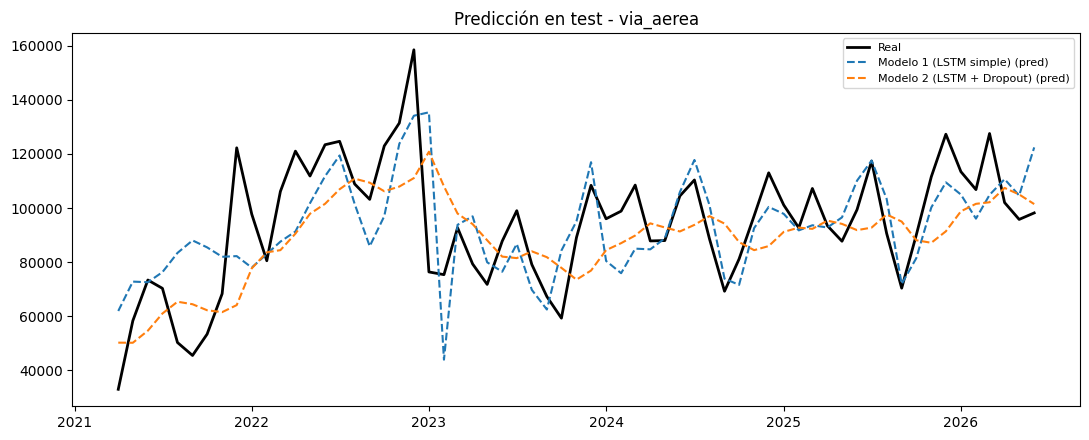

,serie,familia,units,learning_rate,dropout,test_MAE,test_RMSE,es_mejor
0,total,Modelo 1 (LSTM simple),64,0.010,0.0,35687.197334,46499.837002,True
1,total,Modelo 2 (LSTM + Dropout),32,0.001,0.3,39388.643082,50616.310652,False
2,via_aerea,Modelo 1 (LSTM simple),32,0.010,0.0,13939.921978,18115.275391,True
3,via_aerea,Modelo 2 (LSTM + Dropout),32,0.001,0.3,15745.084614,19451.871519,False


In [6]:
todas_grid, todas_finales, mejores_por_serie = [], [], {}
for nombre in SERIES_ELEGIDAS:
    train, test = series_train[nombre], series_test[nombre]
    tabla_grid, finales, mejor_final = tunear_serie(nombre, train, test)
    todas_grid.append(tabla_grid)
    mejores_por_serie[nombre] = mejor_final
    for f in finales:
        todas_finales.append({
            "serie": nombre, "familia": f["familia"], "units": f["units"],
            "learning_rate": f["learning_rate"], "dropout": f["dropout"],
            "test_MAE": f["test_MAE"], "test_RMSE": f["test_RMSE"],
            "es_mejor": f is mejor_final,
        })

tabla_grid_total = pd.concat(todas_grid, ignore_index=True)
tabla_finales = pd.DataFrame(todas_finales)
tabla_grid_total.to_csv(f"{OUT_DIR}/ej1_grid.csv", index=False)
tabla_finales.to_csv(f"{OUT_DIR}/ej1_finales.csv", index=False)
tabla_finales

## Comparación contra los mejores modelos clásicos (Laboratorio 1)

Se recalculan ARIMA, Prophet, Holt-Winters y suavizamiento exponencial simple sobre el **mismo** train/test usado aquí, para que la comparación sea consistente.

In [7]:
def clasicos_benchmark(nombre, train, test):
    from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from pmdarima import auto_arima
    from prophet import Prophet
    import logging
    logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
    logging.getLogger("prophet").setLevel(logging.WARNING)

    horizon = len(test)

    def log_t(s):
        return np.log1p(s) if (s <= 0).any() else np.log(s)

    def inv_log_t(s_log, original):
        return np.expm1(s_log) if (original <= 0).any() else np.exp(s_log)

    resultados = []

    log_train = log_t(train)
    auto = auto_arima(log_train, seasonal=True, m=12, max_p=3, max_q=3,
                       max_P=1, max_Q=1, stepwise=True, suppress_warnings=True,
                       error_action="ignore")
    fit = SARIMAX(log_train, order=auto.order, seasonal_order=auto.seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pred_log = fit.get_forecast(steps=horizon).predicted_mean
    pred_arima = inv_log_t(pred_log, train).clip(lower=0)
    mae, rmse = evaluar(test.values, pred_arima.values)
    resultados.append({"modelo": f"ARIMA{auto.order}x{auto.seasonal_order}", "MAE": mae, "RMSE": rmse})

    df_p = pd.DataFrame({"ds": train.index, "y": train.values})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(df_p)
    fut = pd.DataFrame({"ds": test.index})
    pred_prophet = m.predict(fut)["yhat"].clip(lower=0).values
    mae, rmse = evaluar(test.values, pred_prophet)
    resultados.append({"modelo": "Prophet", "MAE": mae, "RMSE": rmse})

    seasonal_type = "mul" if (train > 0).all() else "add"
    hw = ExponentialSmoothing(train, trend="add", seasonal=seasonal_type, seasonal_periods=12).fit()
    pred_hw = hw.forecast(horizon).clip(lower=0)
    mae, rmse = evaluar(test.values, pred_hw.values)
    resultados.append({"modelo": "Holt-Winters", "MAE": mae, "RMSE": rmse})

    ses = SimpleExpSmoothing(train).fit()
    pred_ses = ses.forecast(horizon).clip(lower=0)
    mae, rmse = evaluar(test.values, pred_ses.values)
    resultados.append({"modelo": "Suavizamiento exponencial simple", "MAE": mae, "RMSE": rmse})

    tabla = pd.DataFrame(resultados).sort_values("RMSE")
    tabla.insert(0, "serie", nombre)
    return tabla

In [8]:
todas_clasicas = []
for nombre in SERIES_ELEGIDAS:
    tabla_clasicos = clasicos_benchmark(nombre, series_train[nombre], series_test[nombre])
    todas_clasicas.append(tabla_clasicos)
    print(f"\nClasicos ({nombre}):")
    print(tabla_clasicos.to_string(index=False))

tabla_clasicos_total = pd.concat(todas_clasicas, ignore_index=True)
tabla_clasicos_total.to_csv(f"{OUT_DIR}/ej1_clasicos.csv", index=False)

Importing plotly failed. Interactive plots will not work.


18:04:07 - cmdstanpy - INFO - Chain [1] start processing


18:04:07 - cmdstanpy - INFO - Chain [1] done processing



Clasicos (total):
serie                           modelo           MAE          RMSE
total                          Prophet 132304.567817 139548.877439
total                     Holt-Winters 134374.813415 146605.600321
total Suavizamiento exponencial simple 165370.149181 180595.742029
total     ARIMA(2, 0, 0)x(1, 0, 1, 12) 183941.807170 198149.819240



Clasicos (via_aerea):
    serie                           modelo          MAE         RMSE
via_aerea                     Holt-Winters 25453.982590 30455.532725
via_aerea Suavizamiento exponencial simple 36970.595572 42141.220228
via_aerea                          Prophet 41300.514107 45687.741327
via_aerea     ARIMA(3, 0, 2)x(1, 0, 1, 12) 73002.349083 76874.847964


## Resumen: mejor LSTM vs. mejor modelo clásico por serie

In [9]:
resumen = []
for nombre in SERIES_ELEGIDAS:
    mejor_lstm = tabla_finales[(tabla_finales["serie"] == nombre) & (tabla_finales["es_mejor"])].iloc[0]
    mejor_clasico = tabla_clasicos_total[tabla_clasicos_total["serie"] == nombre].iloc[0]
    resumen.append({"serie": nombre, "mejor_LSTM": mejor_lstm["familia"],
                     "LSTM_MAE": mejor_lstm["test_MAE"], "LSTM_RMSE": mejor_lstm["test_RMSE"],
                     "mejor_clasico": mejor_clasico["modelo"],
                     "clasico_MAE": mejor_clasico["MAE"], "clasico_RMSE": mejor_clasico["RMSE"]})
pd.DataFrame(resumen)

,serie,mejor_LSTM,LSTM_MAE,LSTM_RMSE,mejor_clasico,clasico_MAE,clasico_RMSE
0,total,Modelo 1 (LSTM simple),35687.197334,46499.837002,Prophet,132304.567817,139548.877439
1,via_aerea,Modelo 1 (LSTM simple),13939.921978,18115.275391,Holt-Winters,25453.982590,30455.532725
